
## **Tackling CIFAR-10 With a DNN/CNN**





In this work, you need to modify the colab file to complete the CIFAR-10 task with a CNN. Please submit the completed colab file to Canvas (PRMLS Day 2 workshop submission).

Moreover, what kind(s) of setup/configuration does the colab training recipe use (not found in our lecturer slides) so that we can rapidly complete model training?

Please provide your answer below:

**[Answer here]**

---



## **1. Import libraries**



In [1]:
# Python ≥3.5 is asserted
import sys
assert sys.version_info >= (3, 5)

# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# Scikit-Learn ≥0.20 is asserted
import sklearn
assert sklearn.__version__ >= "0.20"

# TensorFlow ≥2.0 is asserted
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

# Common imports
import matplotlib
import sklearn
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.callbacks import ModelCheckpoint,CSVLogger,LearningRateScheduler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import optimizers

print("Versions of key libraries")
print("---")
print("tensorflow: ", tf.__version__)
print("numpy:      ", np.__version__)
print("matplotlib: ", matplotlib.__version__)
print("sklearn:    ", sklearn.__version__)

No GPU was detected. CNNs can be very slow without a GPU.
Go to Runtime > Change runtime and select a GPU hardware accelerator.
Versions of key libraries
---
tensorflow:  2.20.0
numpy:       2.0.2
matplotlib:  3.10.0
sklearn:     1.6.1


## **2. Matplotlib setup**

In [2]:
plt.style.use('ggplot')
plt.rcParams['ytick.right']	= True
plt.rcParams['ytick.labelright']=	True
plt.rcParams['ytick.left']	= False
plt.rcParams['ytick.labelleft'] = False
plt.rcParams['font.family']	= 'Arial'

## **3. Data preparation**



In [3]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1141s 7us/step


In [4]:
print("X_train_full.shape =", X_train_full.shape)
print("y_train_full.shape =", y_train_full.shape)
print("X_train.shape =", X_test.shape)
print("y_train.shape =", y_test.shape)
print("X_valid.shape =", X_valid.shape)
print("y_valid.shape =", y_test.shape)
print("X_test.shape =", X_test.shape)
print("y_test.shape =", y_test.shape)


X_train_full.shape = (50000, 32, 32, 3)
y_train_full.shape = (50000, 1)
X_train.shape = (10000, 32, 32, 3, 1)
y_train.shape = (10000, 1)
X_valid.shape = (5000, 32, 32, 3, 1)
y_valid.shape = (10000, 1)
X_test.shape = (10000, 32, 32, 3, 1)
y_test.shape = (10000, 1)


## **4. Define model**

In [12]:
# DNN model here
imgrows=X_train_full.shape[1]
imgclms=X_train_full.shape[2]
channel=3
num_classes = 10

model = keras.Sequential()
model.add(keras.layers.Dense(512, activation='relu', input_dim=3072))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,804,682 (6.88 MB)

 Trainable params: 1,804,682 (6.88 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Import to_categorical for one-hot encoding
# from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_valid_encoded = to_categorical(y_valid, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# Print the shape of the encoded labels
print(y_train_encoded.shape)
print(y_valid_encoded.shape)
print(y_test.shape)
print(y_test_encoded.shape)

(45000, 10)
(5000, 10)
(10000, 1)
(10000, 10)


In [14]:
# Set up optimizer
# from tensorflow.keras import optimizers
optmz = tf.keras.optimizers.RMSprop(learning_rate=0.0001)
model.compile(loss="categorical_crossentropy", optimizer=optmz, metrics=["accuracy"])

# create checkpoints to save model during training and save training data into csv
# from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
modelname = "cifar10"
filepath = modelname + ".keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_acc', verbose=0, save_best_only=True, mode='max')
csv_logger = CSVLogger(modelname+'.csv')
callbacks_list = [checkpoint, csv_logger]



## **5 & 6. Train and test a model**

In [15]:
# train a model
# Note: Reshape the input data to flatten the images (for DNN)
X_train_flattened = X_train.reshape(X_train.shape[0], -1)  # -1 infers the remaining dimension
X_valid_flattened = X_valid.reshape(X_valid.shape[0], -1)
X_test_flattened = X_test.reshape(X_test.shape[0], -1)
X_train = X_train_flattened
X_valid = X_valid_flattened
X_test = X_test_flattened

history = model.fit(X_train, y_train_encoded, epochs=4, validation_data=(X_valid, y_valid_encoded), callbacks=callbacks_list)
score = model.evaluate(X_test, y_test_encoded)
X_new = X_test[:10] # pretend we have new images
y_pred = model.predict(X_new)

Epoch 1/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.4109 - loss: 1.6615 - val_accuracy: 0.4496 - val_loss: 1.5672
Epoch 2/4


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.4998 - loss: 1.4197 - val_accuracy: 0.4836 - val_loss: 1.4886
Epoch 3/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.5491 - loss: 1.2893 - val_accuracy: 0.4972 - val_loss: 1.4512
Epoch 4/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.5871 - loss: 1.1822 - val_accuracy: 0.5156 - val_loss: 1.4130
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5206 - loss: 1.4111
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


In [16]:
model.save_weights(modelname+".weights.h5", overwrite=True)
print (X_test.shape)
print (y_test_encoded.shape)
print (score)

print ("modelname =", modelname)
!pwd
!date
!ls -lh

(10000, 3072)
(10000, 10)
[1.4111114740371704, 0.5206000208854675]
modelname = cifar10
/content
Fri Aug 14 12:57:53 PM UTC 2026
total 28M
-rw-r--r-- 1 root root  357 Aug 14 12:57 cifar10.csv
-rw-r--r-- 1 root root  14M Aug 14 12:57 cifar10.keras
-rw-r--r-- 1 root root  14M Aug 14 12:57 cifar10.weights.h5
drwxr-xr-x 1 root root 4.0K Aug 10 13:26 sample_data


In [17]:
# Calculate accuracy and confusion matrix
# import sklearn.metrics as metrics
#X_new = X_test[:10] # pretend we have new images
#y_new = y_test_encoded[:10]
#y_pred = model.predict(X_new)
y_pred = model.predict(X_test)

predout = np.argmax(y_pred, axis=1)
testout = np.argmax(y_test_encoded, axis=1)
# for Cifar 10
labelname = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
unique_classes = np.unique(predout)
adjusted_labelname = [labelname[i] for i in unique_classes] # Select labels corresponding to predicted classes

testScores = metrics.accuracy_score(testout,predout)
confusion = metrics.confusion_matrix(testout,predout)

print("Best accuracy (on testing dataset): %.2f%%" % (testScores*100))
print(metrics.classification_report(testout,predout,target_names=adjusted_labelname,digits=4))
print(confusion)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Best accuracy (on testing dataset): 52.06%
              precision    recall  f1-score   support

    airplane     0.5507    0.6080    0.5779      1000
  automobile     0.5773    0.6870    0.6274      1000
        bird     0.4656    0.3180    0.3779      1000
         cat     0.3842    0.2970    0.3350      1000
        deer     0.4927    0.3690    0.4220      1000
         dog     0.4515    0.4190    0.4346      1000
        frog     0.4871    0.6590    0.5601      1000
       horse     0.5349    0.6440    0.5844      1000
        ship     0.6302    0.6630    0.6462      1000
       truck     0.5622    0.5420    0.5519      1000

    accuracy                         0.5206     10000
   macro avg     0.5136    0.5206    0.5118     10000
weighted avg     0.5136    0.5206    0.5118     10000

[[608  59  44  10  19  15  29  27 144  45]
 [ 35 687   6  14   6   9  19  27  53 144]
 [105  29 318  80 112  92 131  95  15  23]
 [ 61  37  45 297  47 202 15

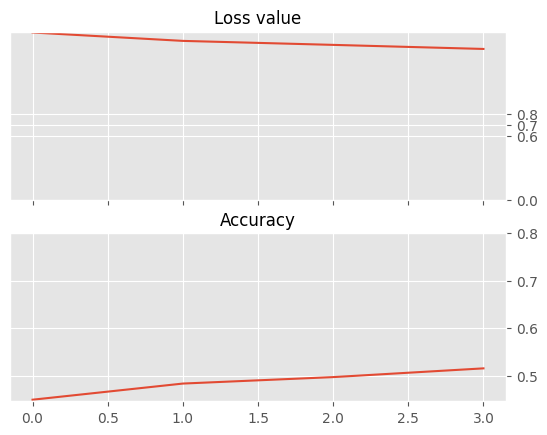

In [18]:
# plot the result
# import pandas as pd
records = pd.read_csv(modelname+'.csv')
plt.figure()
plt.subplot(211)
plt.plot(records['val_loss'])
plt.yticks([0.00,0.60,0.70,0.80])
plt.title('Loss value',fontsize=12)
ax = plt.gca()
ax.set_xticklabels([])
plt.subplot(212)
#plt.plot(records['val_acc'])
plt.plot(records['val_accuracy'])
#plt.plot(records.get('val_accuracy', records.get('val_acc')))
plt.yticks([0.5,0.6,0.7,0.8])
plt.title('Accuracy',fontsize=12)
plt.show()